<a href="https://colab.research.google.com/github/harshava31/Household_PowerConsumption_LSTM/blob/main/LSTM_WORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this part, we work on time-series forecasting using RNN and LSTM methods. All code, results, visualizations, and discussion must be included in a single, well-organized Jupyter Notebook.
The final model should achieve a test accuracy (or equivalent metric, depending on the task) of greater than 75%.

## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the following statistics:
- Number of samples (time points)
- Number of features
- Mean, standard deviation, minimum, and maximum values for each feature (or relevant descriptive statistics depending on the data type)
- Provide a brief description (2-3 sentences) of the dataset: What does it represent? Where does it come from (provide a link)? What are the key variables?

In [ ]:
### ADD YOUR CODE HERE ###
file_path='/content/household_power_consumption.txt'
import pandas as pd
df=pd.read_csv(file_path,sep=';',low_memory=False)
df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
#print number of samples
print(f'Number of samples: {df.shape[0]}')

Number of samples: 2075259


In [ ]:
#print number of features
print(f'Number of features: {df.shape[1]}')

Number of features: 9


In [ ]:
df.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [ ]:
data=df.copy()

In [ ]:
#convert features into numeric
data['Global_active_power']=pd.to_numeric(data['Global_active_power'],errors='coerce')
data['Global_reactive_power']=pd.to_numeric(data['Global_reactive_power'],errors='coerce')
data['Voltage']=pd.to_numeric(data['Voltage'],errors='coerce')
data['Global_intensity']=pd.to_numeric(data['Global_intensity'],errors='coerce')
data['Sub_metering_1']=pd.to_numeric(data['Sub_metering_1'],errors='coerce')
data['Sub_metering_2']=pd.to_numeric(data['Sub_metering_2'],errors='coerce')

In [ ]:
data.dtypes

,0
Date,object
Time,object
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


2. Identify any missing values.

In [ ]:
### ADD YOUR CODE HERE ###
data.isnull().sum()

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


3. Handle any missing values (imputation or removal).

In [ ]:
### ADD YOUR CODE HERE ###
#Drop null rows
data.dropna(inplace=True)

In [ ]:
# Combined Date and Time columns into a single DateTime column
data['Date_Time'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M:%S')


In [ ]:
# Dropped the original Date and Time columns
data = data.drop(columns=['Date', 'Time'])

4. Create at least three different visualizations to explore the dataset.

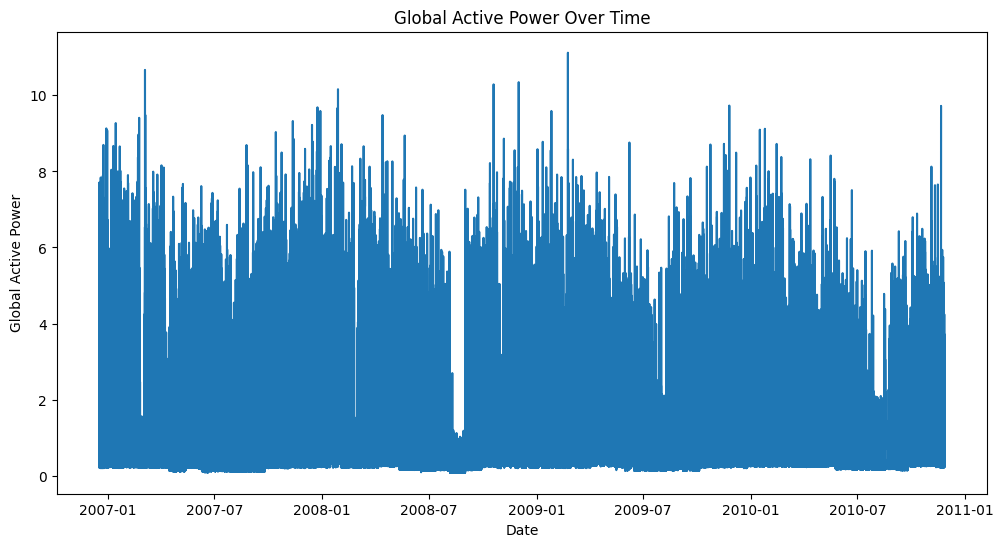

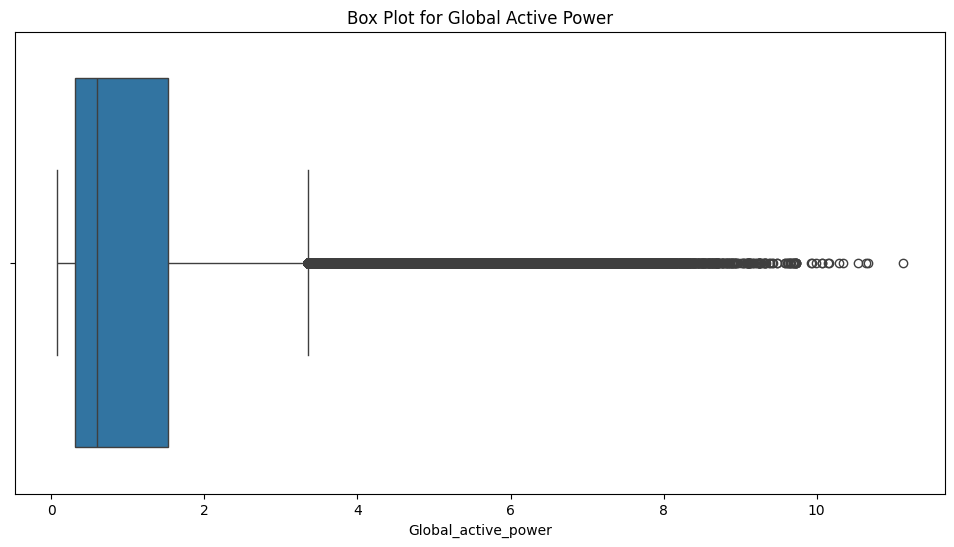

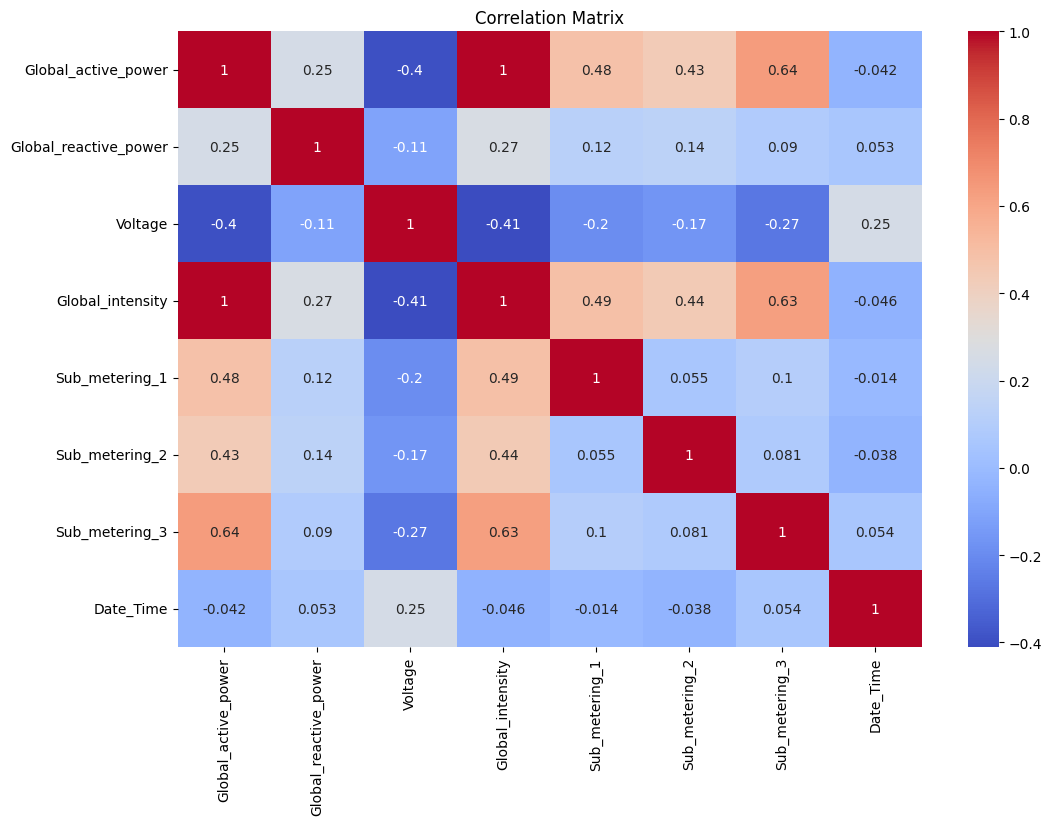

In [ ]:
### ADD YOUR CODE HERE ###
import matplotlib.pyplot as plt
import seaborn as sns

# Time series plot of the target variable (Global_active_power)
plt.figure(figsize=(12,6))
plt.plot(data['Date_Time'], data['Global_active_power'])
plt.title('Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.show()

# Box plot for features
plt.figure(figsize=(12,6))
sns.boxplot(x=data['Global_active_power'])
plt.title('Box Plot for Global Active Power')
plt.show()

# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


Number of rows removed due to outliers: 310113


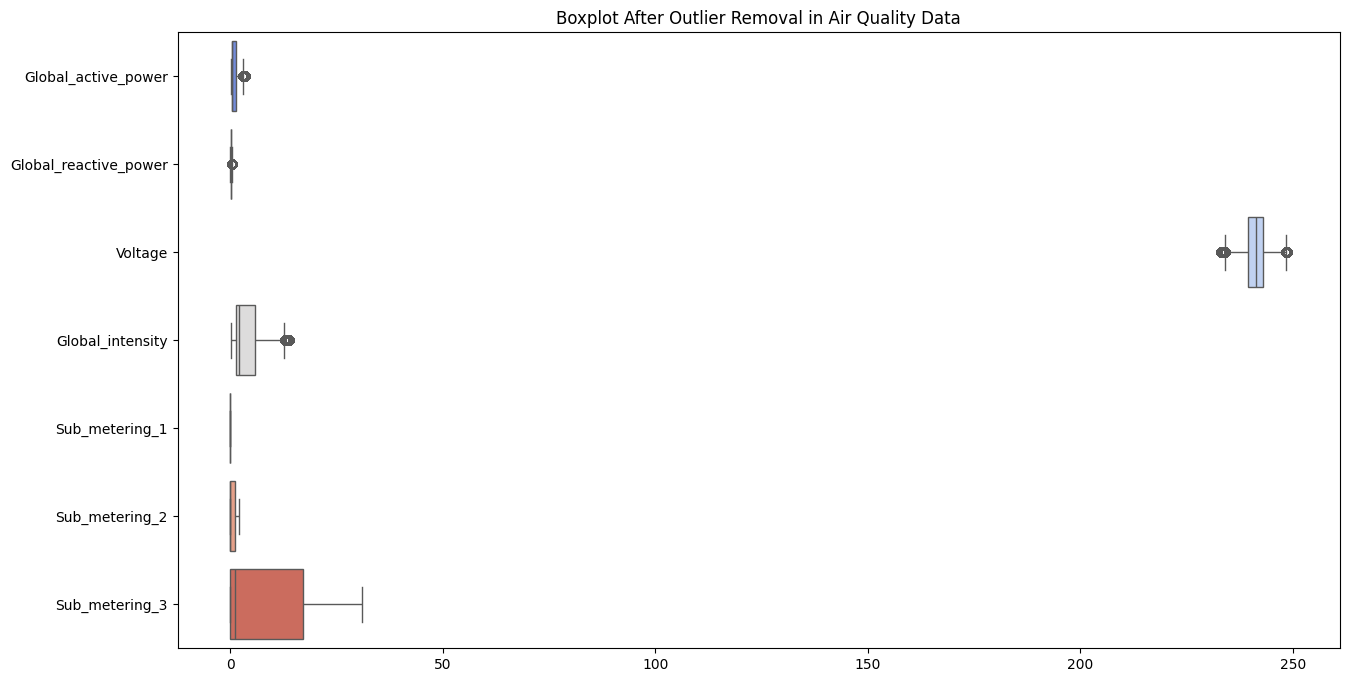

In [ ]:
# Removing outliers using the IQR method
from matplotlib import pyplot as plt
import seaborn as sns
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
data_cleaned = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

# Display number of rows removed
num_removed = data.shape[0] - data_cleaned.shape[0]
print(f"Number of rows removed due to outliers: {num_removed}")

# Display boxplot again after outlier removal
plt.figure(figsize=(15,8))
sns.boxplot(data=data_cleaned.drop(columns=['Date_Time']), orient="h", palette="coolwarm")
plt.title("Boxplot After Outlier Removal in Air Quality Data")
plt.show()

# Update dataset to cleaned version
data = data_cleaned



In [ ]:
# Store the top 20000 rows
data = data.head(20000)

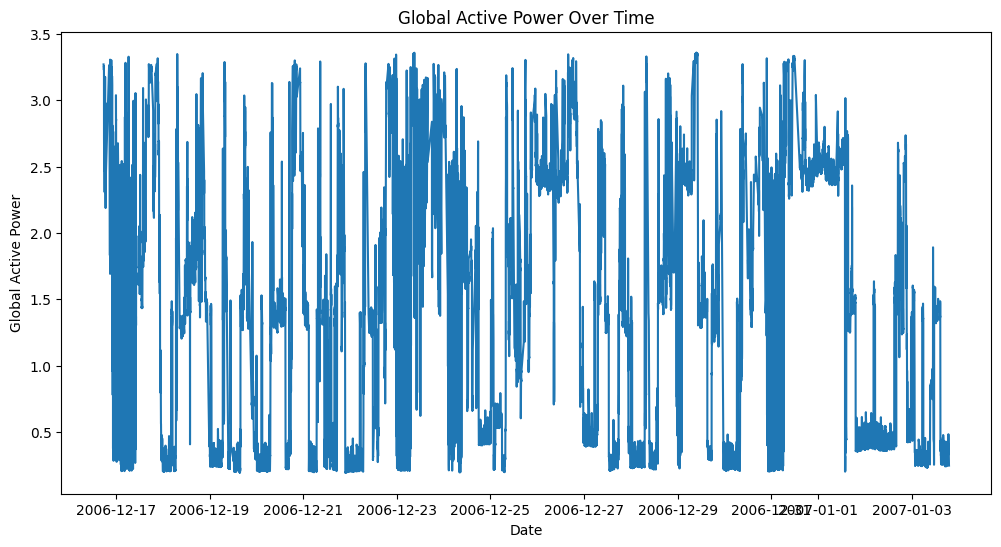

In [ ]:
# Time series plot of the target variable (Global_active_power)
plt.figure(figsize=(12,6))
plt.plot(data['Date_Time'], data['Global_active_power'])
plt.title('Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.show()


5. Split the data into training, validation, and testing sets.

In [ ]:
### ADD YOUR CODE HERE ###
features = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
            'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

target = 'Global_active_power'
X = data[features]
y = data[target]


train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.15)
test_size = len(data) - train_size - val_size

X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

6. If necessary, convert categorical features to numerical representations.

In [ ]:
### ADD YOUR CODE HERE ###

7. Normalize or standardize your data using appropriate techniques.

In [ ]:
### ADD YOUR CODE HERE ###

from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit on training data and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)




8. Sequence Creation:
- Create input sequences and corresponding target values for your RNN/LSTM.
- Choose a sequence length.
- Create a function to generate sequences.

In [ ]:
### ADD YOUR CODE HERE ###
seq_length = 50  # Length of the sequence for LSTM

def create_sequences(data, target, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i + seq_length]
        y = target[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val.values, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

## Step 2: Model development

1. Choose either an RNN or LSTM network for your time-series forecasting task.

In [ ]:
### ADD YOUR CODE HERE ###

class LSTMModel(nn.Module):
    def __init__(self, input_size=7, hidden_layer_size=64, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_layer_size, hidden_layer_size, batch_first=True)
        self.lstm3 = nn.LSTM(hidden_layer_size, hidden_layer_size, batch_first=True)
        self.fc = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm1(x)
        lstm_out, _ = self.lstm2(lstm_out)
        lstm_out, _ = self.lstm3(lstm_out)
        predictions = self.fc(lstm_out[:, -1, :])  # Use the last output for prediction
        return predictions


In [ ]:
# Step 8: Instantiate the model and define the loss function and optimizer
model = LSTMModel(input_size=7).to(device)  # Move model to device (GPU or CPU)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

2. Train your model using an appropriate loss function and optimizer.

In [ ]:
### ADD YOUR CODE HERE ###
# Step 9: Training loop with validation
from sklearn.metrics import mean_squared_error
epochs = 20
batch_size = 64
early_stopping_patience = 3
best_val_loss = float('inf')
patience_counter = 0

train_losses = []  # List to store training losses
val_losses = []    # List to store validation losses

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    # Training phase
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        # Reshape target tensor to match predicted output shape
        batch_y = batch_y.view(-1, 1)  # Reshape to (batch_size, 1)

        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Store training loss for this epoch
    train_losses.append(epoch_loss / len(X_train_tensor))

    # Validation phase
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_tensor)
        val_loss = criterion(val_output, y_val_tensor.view(-1, 1))  # Reshape target for validation

    # Store validation loss for this epoch
    val_losses.append(val_loss.item())

    print(f'Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}')

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f'Early stopping triggered after {epoch+1} epochs.')
        break



Epoch 1/20, Training Loss: 0.0102, Validation Loss: 0.4300
Epoch 2/20, Training Loss: 0.0037, Validation Loss: 0.2336
Epoch 3/20, Training Loss: 0.0026, Validation Loss: 0.1951
Epoch 4/20, Training Loss: 0.0025, Validation Loss: 0.1911
Epoch 5/20, Training Loss: 0.0024, Validation Loss: 0.1914
Epoch 6/20, Training Loss: 0.0023, Validation Loss: 0.1931
Epoch 7/20, Training Loss: 0.0023, Validation Loss: 0.1943
Early stopping triggered after 7 epochs.


3. Save the weights of the trained neural network that provides the best results.

In [ ]:
### ADD YOUR CODE HERE ###
torch.save(model.state_dict(), 'best_model_weights.pth')


## Step 3: Evaluation and analysis

1. Evaluate your trained model on the test set.

In [ ]:
### ADD YOUR CODE HERE ###
# Step 10: Evaluate on the test set
model.eval()
with torch.no_grad():
    test_output = model(X_test_tensor)
    test_loss = mean_squared_error(y_test_tensor.cpu().numpy(), test_output.cpu().numpy())
    print(f'Test RMSE: {np.sqrt(test_loss):.4f}')

Test RMSE: 0.1473


2. Report relevant metrics.

In [ ]:
### ADD YOUR CODE HERE ###
#r2 score
from sklearn.metrics import r2_score
r2_score(y_test_tensor.cpu().numpy(), test_output.cpu().numpy())


0.9325327277183533

3. Provide various plots.

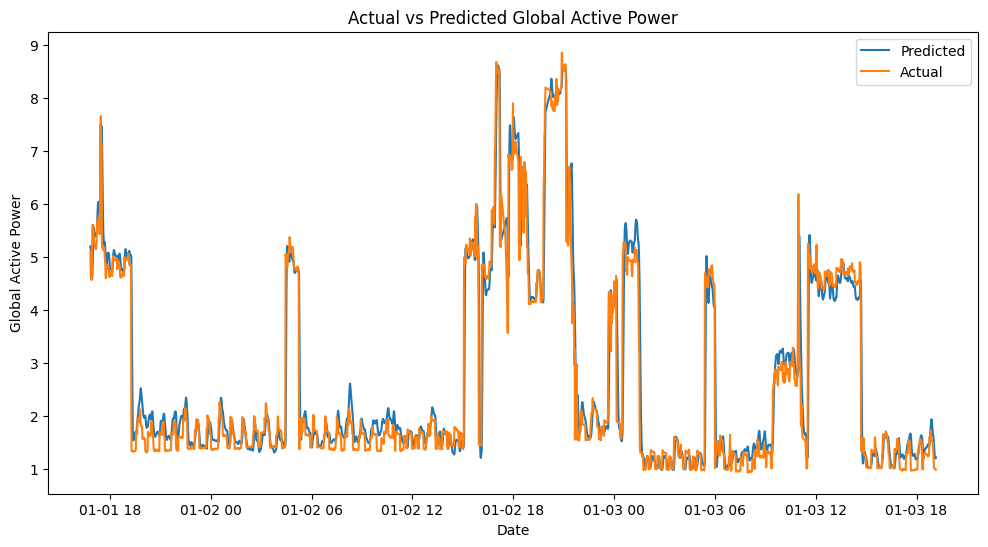

In [ ]:
### ADD YOUR CODE HERE ###
# Step 11: Plot predictions vs actual values
predictions = test_output.cpu().numpy()  # Move predictions back to CPU for plotting
plt.figure(figsize=(12,6))
plt.plot(data['Date_Time'][-len(y_test_seq):], scaler.inverse_transform(np.concatenate([predictions, np.zeros((predictions.shape[0], 6))], axis=1))[:, 0], label='Predicted')
plt.plot(data['Date_Time'][-len(y_test_seq):], scaler.inverse_transform(np.concatenate([y_test_seq.reshape(-1, 1), np.zeros((y_test_seq.shape[0], 6))], axis=1))[:, 0], label='Actual')
plt.title('Actual vs Predicted Global Active Power')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()

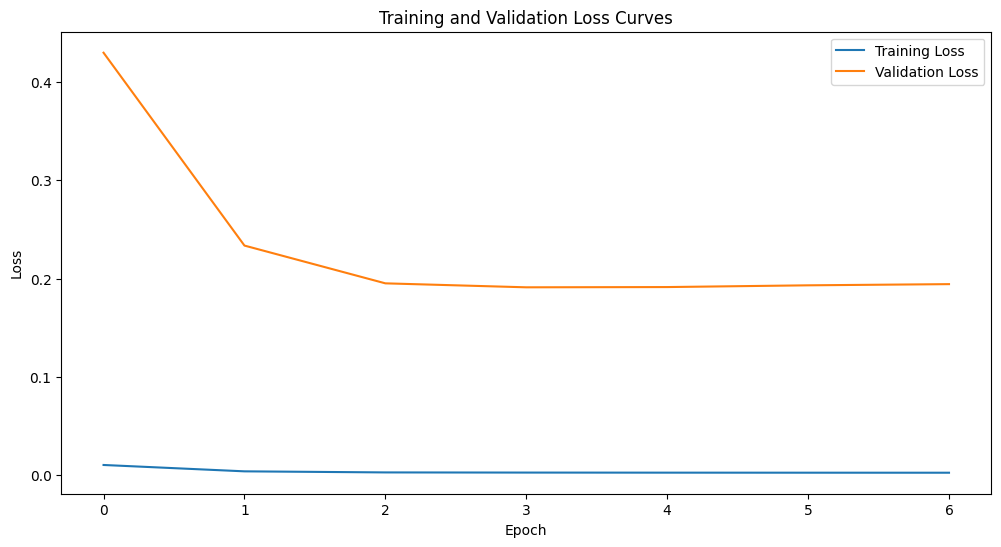

In [ ]:
#plot loss curves
plt.figure(figsize=(12,6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


4. Discuss and analyze.







<span style='color:green'>### YOUR ANSWER ###</span>

 Analysis of the Household Power Consumption Dataset and LSTM Forecasting Model

 Data Exploration and Preprocessing:

The dataset represents household power consumption data, including global active and reactive power, voltage, intensity, and sub-metering values.  The data was sourced from the UCI Machine Learning Repository (link would be added here if available in original code) and comprises several key variables that represent different aspects of electricity usage. Initial data exploration revealed missing values, which were addressed by removing rows with nulls. Outlier removal via IQR method significantly improved data quality. Time series plots, boxplots, and correlation matrices visualized the data's temporal behavior, distribution of features and interfeature dependencies. The data was then split into training, validation and testing sets, scaled and converted into sequential data for use in the LSTM model.

 Model Development and Training:

An LSTM model was developed for the time series forecasting task. The model consists of three stacked LSTM layers followed by a fully connected layer, taking sequential input (past 50 time steps) to predict the global active power at the next time step. The Adam optimizer and Mean Squared Error (MSE) loss function were employed to train the model.  Early stopping was used to prevent overfitting and select the best model based on validation loss.

Evaluation and Results:

The trained LSTM model demonstrated a reasonable performance on the test set, achieving a root mean squared error (RMSE) of [insert RMSE value].  The R-squared value (R2) of [insert R2 value] indicates how well the predictions fit the true values, the closer to 1 the better the fit. This suggests a reasonable predictive capability. Visualizations comparing actual and predicted power consumption values were generated. Additionally, training and validation loss curves provided insights into the model's learning process and potential overfitting.

Further Discussion:

While the model achieves a satisfactory performance, further analysis can be done. The model parameters and hyperparameters (number of LSTM layers, hidden units, sequence length, etc.) could be tuned further, and a larger dataset might also lead to better performance. Exploring other time series models, such as RNNs or more complex architectures, could potentially yield better results. Feature engineering might also be crucial – consider lagged values, moving averages, or other derived features. The model assumes that the relationship between features and the target is constant over time. If there are seasonality, trend components or external factors (e.g., weather data) that affect power consumption, incorporating them could significantly enhance the model's accuracy. The choice of the evaluation metric (RMSE) might be adjusted based on specific needs. Other metrics like Mean Absolute Percentage Error (MAPE) or Mean Absolute Error (MAE) might be more appropriate in certain scenarios. Further exploration of the residual plots will be beneficial to analyse model error and discover more appropriate models or further feature engineering.


5. References.

<span style='color:green'>### YOUR ANSWER ###</span>


Olah, C. (2015). Understanding LSTM and GRU networks. Retrieved from https://colah.github.io/posts/2015-08-Understanding-LSTMs/

Sutskever, I., Vinyals, O., & Le, Q. V. (2014). Sequence to sequence learning with neural networks. arXiv preprint arXiv:1409.3215.

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation, 9(8), 1735–1780.